# 01 — EDA: разведочный анализ входных PDF-паспортов

**Задача проекта:** автономно извлекать структурированные поля из PDF-паспортов промышленного оборудования (OCR + правила + опциональная LLM).

Этот ноутбук — разведочный анализ корпуса входных документов. У нас нет классического «датасета с лейблами»: данные — это сами PDF-файлы (см. папку `project/приложения/`) и контрольная выборка с ожидаемыми значениями полей (`project/samples/control_samples.json`).

Цели EDA:
1. Понять, какие типы документов встречаются (одиночные паспорта, групповые, перечни шкафов, экранные формы).
2. Оценить, в каких документах есть embedded-текст (PDF-текстовый слой), а где придётся идти через OCR.
3. Посмотреть распределение по числу страниц, размеру файла, наличию ключевых полей.
4. Прикинуть, какие сложности встретятся при extraction (шумные сканы, нестандартные структуры, низкое разрешение).

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

DOCS_DIR = PROJECT_ROOT / 'приложения'
SAMPLES_FILE = PROJECT_ROOT / 'samples' / 'control_samples.json'

print('Корень проекта:', PROJECT_ROOT)
print('Документы:', DOCS_DIR)
print('Контрольный набор:', SAMPLES_FILE)

Корень проекта: C:\Users\Grafzilla\Desktop\aie-project-Bukhna\aie_project_Bukhna\project
Документы: C:\Users\Grafzilla\Desktop\aie-project-Bukhna\aie_project_Bukhna\project\приложения
Контрольный набор: C:\Users\Grafzilla\Desktop\aie-project-Bukhna\aie_project_Bukhna\project\samples\control_samples.json


## 1. Корпус документов: общий обзор

In [2]:
import pandas as pd

docs = sorted(DOCS_DIR.glob('*.pdf'))
print(f'Всего PDF в корпусе: {len(docs)}\n')

corpus_df = pd.DataFrame([
    {'file': d.name, 'size_kb': round(d.stat().st_size / 1024, 1)}
    for d in docs
]).sort_values('size_kb', ascending=False).reset_index(drop=True)

corpus_df

Всего PDF в корпусе: 7



,file,size_kb
0,Приложение 3 к задаче 1 Групповой паспорт TECO...,3952.4
1,Приложение 2 к задаче 1 Паспорт с одним заводс...,871.4
2,Приложение 5 к задаче 1 Разбор паспорта.docx.pdf,779.2
3,Приложение 1 к задаче 1 Паспорт без заводского...,652.0
4,Приложене 6 к задаче 1 Экранная форма исходной...,289.4
5,Задача 1_Автоматизация обработки паспортов (ло...,150.9
6,Приложение 4 к задаче 1 Разбор паспорта.pdf,128.2


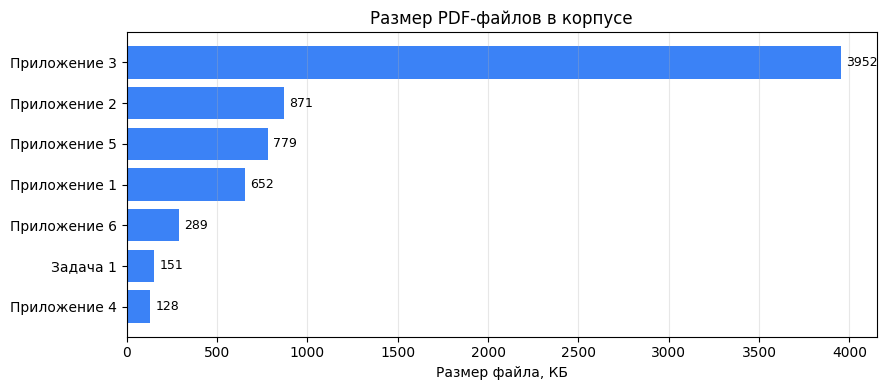

In [3]:
import matplotlib.pyplot as plt
import re

def _shortname(name):
    m = re.match(r'Прилож\S*\s+(\d+)', name)
    if m:
        return f'Приложение {m.group(1)}'
    if name.startswith('Задача'):
        return 'Задача 1'
    return name[:20]

short_names = [_shortname(n) for n in corpus_df['file']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(short_names, corpus_df['size_kb'], color='#3b82f6')
ax.set_xlabel('Размер файла, КБ')
ax.set_title('Размер PDF-файлов в корпусе')
ax.invert_yaxis()
for i, v in enumerate(corpus_df['size_kb']):
    ax.text(v + 30, i, f'{v:.0f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()


In [4]:
import fitz  # PyMuPDF

OCR_THRESHOLD = 120  # из конфига: OCR_IF_EMBEDDED_CHARS

rows = []
for path in docs:
    pdf = fitz.open(str(path))
    pages = pdf.page_count
    embedded_chars = sum(len((pdf[i].get_text('text') or '').strip()) for i in range(pages))
    pdf.close()
    rows.append({
        'file': path.name,
        'pages': pages,
        'embedded_chars': embedded_chars,
        'avg_chars_per_page': embedded_chars // max(1, pages),
        'mostly_scan': embedded_chars < OCR_THRESHOLD * pages,
    })

structure_df = pd.DataFrame(rows)
structure_df

,file,pages,embedded_chars,avg_chars_per_page,mostly_scan
0,Задача 1_Автоматизация обработки паспортов (ло...,2,5549,2774,False
1,Приложене 6 к задаче 1 Экранная форма исходной...,1,0,0,True
2,Приложение 1 к задаче 1 Паспорт без заводского...,1,0,0,True
3,Приложение 2 к задаче 1 Паспорт с одним заводс...,2,0,0,True
4,Приложение 3 к задаче 1 Групповой паспорт TECO...,4,0,0,True
5,Приложение 4 к задаче 1 Разбор паспорта.pdf,1,2267,2267,False
6,Приложение 5 к задаче 1 Разбор паспорта.docx.pdf,1,0,0,True


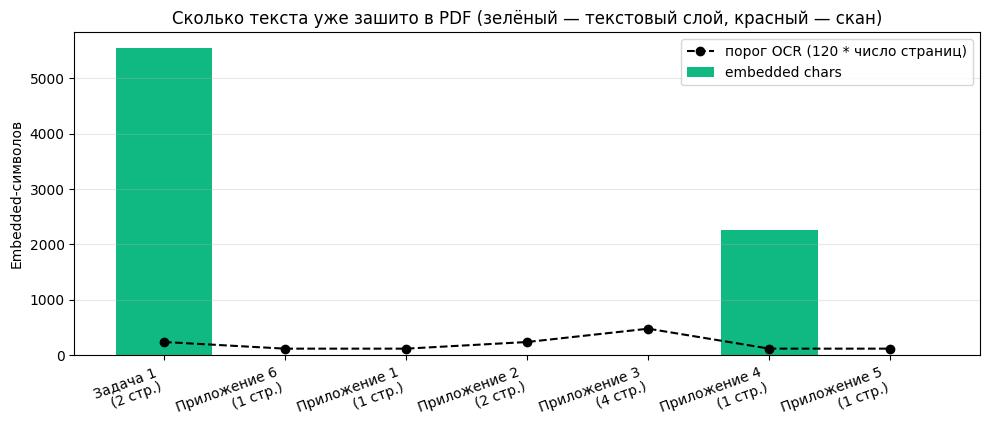

In [5]:
short = [_shortname(n) for n in structure_df['file']]
x_labels = [f'{s}\n({p} стр.)' for s, p in zip(short, structure_df['pages'])]
threshold_per_doc = structure_df['pages'] * OCR_THRESHOLD

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#ef4444' if scan else '#10b981' for scan in structure_df['mostly_scan']]
ax.bar(short, structure_df['embedded_chars'], color=colors, label='embedded chars')
ax.plot(short, threshold_per_doc, 'k--', marker='o', linewidth=1.5,
        label=f'порог OCR ({OCR_THRESHOLD} * число страниц)')
ax.set_ylabel('Embedded-символов')
ax.set_title('Сколько текста уже зашито в PDF (зелёный — текстовый слой, красный — скан)')
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=20, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


**Что смотрим:**
- `embedded_chars` низкий → PDF почти наверняка скан → OCR обязателен.
- `embedded_chars` высокий → текстовый слой есть → можно сначала попробовать прочитать его, а OCR оставить как fallback (порог `OCR_IF_EMBEDDED_CHARS=120` в конфиге как раз про это).
- `pages` разное → пайплайн должен корректно обрабатывать многостраничные документы и не падать на однопотиях.

## 3. Контрольная выборка: распределение ожидаемых полей

В контроле 4 типа документов:

- **Одиночный паспорт** (`single_passport`) — паспорт одного изделия (с серийным номером или без).
- **Групповой паспорт** (`group_passport`) — один документ на партию однотипных изделий.
- **Перечень шкафа** (`cabinet_list`) — спецификация шкафа с составом оборудования.
- **Не паспорт** (`unknown`) — служебные документы из набора: описание задачи, экранная форма для заполнения данных. На таких файлах пайплайн должен корректно ставить `document_type=unknown` и не пытаться извлечь поля.


In [6]:
with SAMPLES_FILE.open('r', encoding='utf-8') as f:
    control = json.load(f)

samples = control.get('samples', [])
fields = control.get('fields', [])
print('Всего контрольных примеров:', len(samples))
print('Целевые поля:', fields)

field_presence = Counter()
doc_types = Counter()
for s in samples:
    exp = s.get('expected', {})
    for k, v in exp.items():
        if v:
            field_presence[k] += 1
    if 'document_type' in exp:
        doc_types[exp['document_type']] += 1

print()
print('Заполненность полей в контроле:')
for k, v in field_presence.most_common():
    print(f'  {k:<20} {v}')

print()
print('Распределение типов документов:')
for k, v in doc_types.most_common():
    print(f'  {k:<20} {v}')


Всего контрольных примеров: 6
Целевые поля: ['document_type', 'kod_dokumenta', 'naimenovanie', 'kod_zakaza', 'zavodskie_nomera', 'data_vypuska', 'proizvoditel']

Заполненность полей в контроле:
  document_type        6
  kod_dokumenta        4
  naimenovanie         4
  proizvoditel         3
  kod_zakaza           1
  zavodskie_nomera     1
  data_vypuska         1

Распределение типов документов:
  single_passport      2
  unknown              2
  group_passport       1
  cabinet_list         1


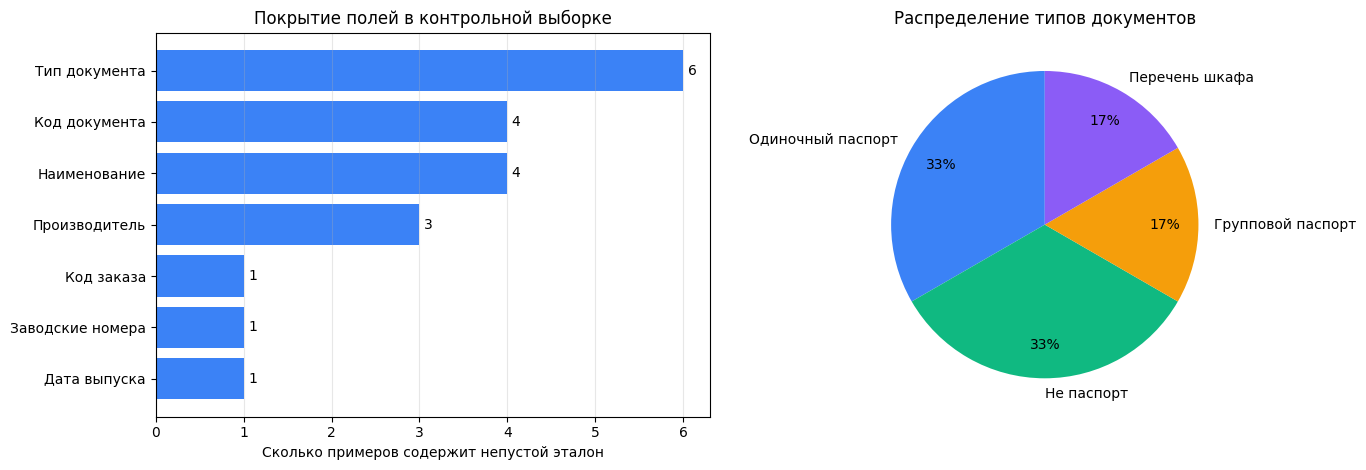

In [7]:
FIELD_RU = {
    'document_type':    'Тип документа',
    'kod_dokumenta':    'Код документа',
    'naimenovanie':     'Наименование',
    'proizvoditel':     'Производитель',
    'data_vypuska':     'Дата выпуска',
    'kod_zakaza':       'Код заказа',
    'zavodskie_nomera': 'Заводские номера',
}
DOCTYPE_RU = {
    'single_passport': 'Одиночный паспорт',
    'group_passport':  'Групповой паспорт',
    'cabinet_list':    'Перечень шкафа',
    'unknown':         'Не паспорт',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

field_items = field_presence.most_common()
field_names_ru = [FIELD_RU.get(n, n) for n, _ in field_items]
field_counts = [c for _, c in field_items]
ax1.barh(field_names_ru, field_counts, color='#3b82f6')
ax1.set_xlabel('Сколько примеров содержит непустой эталон')
ax1.set_title('Покрытие полей в контрольной выборке')
ax1.invert_yaxis()
for i, v in enumerate(field_counts):
    ax1.text(v + 0.05, i, str(v), va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

dt_items = doc_types.most_common()
dt_labels = [DOCTYPE_RU.get(n, n) for n, _ in dt_items]
dt_counts = [c for _, c in dt_items]
palette = ['#3b82f6', '#10b981', '#f59e0b', '#8b5cf6', '#ef4444']
ax2.pie(dt_counts, labels=dt_labels, autopct='%1.0f%%',
        colors=palette[:len(dt_labels)], startangle=90, pctdistance=0.78)
ax2.set_title('Распределение типов документов')

fig.tight_layout()
plt.show()


## 4. Выводы EDA

- Корпус **маленький** (≈ 7 документов): это не классический ML-сетап с тысячами примеров, а реалистичный «промышленный» кейс по IDP (Intelligent Document Processing), где разнообразие важнее объёма.
- Типы документов разнородные: одиночные паспорта, групповые паспорта, перечни шкафа, экранные формы. Под каждый тип в правилах прописаны отдельные эвристики (`_extract_structured_from_text`, `parse_cabinet_document`).
- Часть документов содержит embedded-текст, часть — сканы. Пайплайн должен уметь оба сценария: смотрим на embedded и, если его мало, идём в OCR.
- Контрольная выборка покрывает 7 полей; не все поля заполнены в каждом примере. При оценке мы сравниваем только непустые `expected` (это честный подход: метрика отражает качество там, где есть эталон).

Следующий шаг: **02_baselines.ipynb** — сравнение baseline (OCR + правила) против улучшенного варианта (OCR + правила + LLM) на этой контрольной выборке.